# CT Reconstruction with 3D Gaussian Splatting

Reconstruct a 3D volume from CT projections using **isotropic 3D Gaussians** rendered
through gsplat's orthographic pipeline from multiple angles.

**Pipeline:**
$$\text{3D Gaussians} \xrightarrow[\text{angles } \theta_i]{\text{ortho proj}} \text{gsplat compositing} \rightarrow \hat{p}_i \xrightarrow{\text{MSE}} \text{loss} \rightarrow \text{update}$$

**Key design choices:**
- **Isotropic Gaussians**: single scale $\sigma$ per Gaussian (same in all 3 directions)
- **Multi-angle orthographic projection**: parallel-beam geometry, rotation around z-axis
- **Mini-batch training**: random subset of projections per gradient step
- **Adaptive control**: pruning + splitting every 500 iterations
- **Grayscale**: single intensity per Gaussian (replicated to 3 RGB channels for gsplat)
- **Fixed quaternions**: rotation is irrelevant for isotropic Gaussians

## 1. Imports and Setup

In [ ]:
import sys, math, time
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from torch import optim
from torch.amp import GradScaler, autocast
from gsplat import rasterization

import lovely_tensors as lt
lt.monkey_patch()

# ── Project path ──────────────────────────────────────────────────────────
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

from gsplat_compress import GaussianParams
from inct.dataset_slices import ProjectionSliceDataset

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['image.cmap'] = 'gray'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}  |  PyTorch {torch.__version__}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name()}")
print("Imports ready")

Device: cuda  |  PyTorch 2.10.0+cu128
GPU: NVIDIA A100 80GB PCIe
Imports ready


## 2. Load CT Projections

Load N projections from `ProjectionSliceDataset`. These are parallel-beam projections
evenly spaced from 0° to 180°. Each projection is a 2D image of shape (H, W).

/opt/conda/lib/python3.10/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: 'Could not load this library: /opt/conda/lib/python3.10/site-packages/torchvision/image.so'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


✅ Found parameters in JC_62d.log: {'num_darks': 10, 'num_flats': 100, 'num_projections': 1501}
📂 Loaded folder: file_1_extracted
   Total TIFF files: 1711
   Darks: 10, Flats: 100, Projections: 1501
   Image dimensions: 2560 x 2160
   Use attenuation: False
✅ Loaded cached raw data from .tomography_cache_raw.npz
   Range: [6814.0000, 51523.0000]
ProjectionSliceDataset:
  Volume shape: (1080, 1280, 10)
  Slice dimension: 2
  Slices per batch: 1
  Voxels per slice (dim=2): 1,382,400
Loading 10 projections...
Volume shape: (1080, 1280, 10)
Total voxels: 13,824,000
Value range: [8992.6250, 46449.3125]

Loaded 10 projections (indices 0–9 of 1501 total), each 1080x1280
Value range: [0.0000, 1.0000]
GT tensor: torch.Size([10, 1080, 1280, 3]) on cuda:0


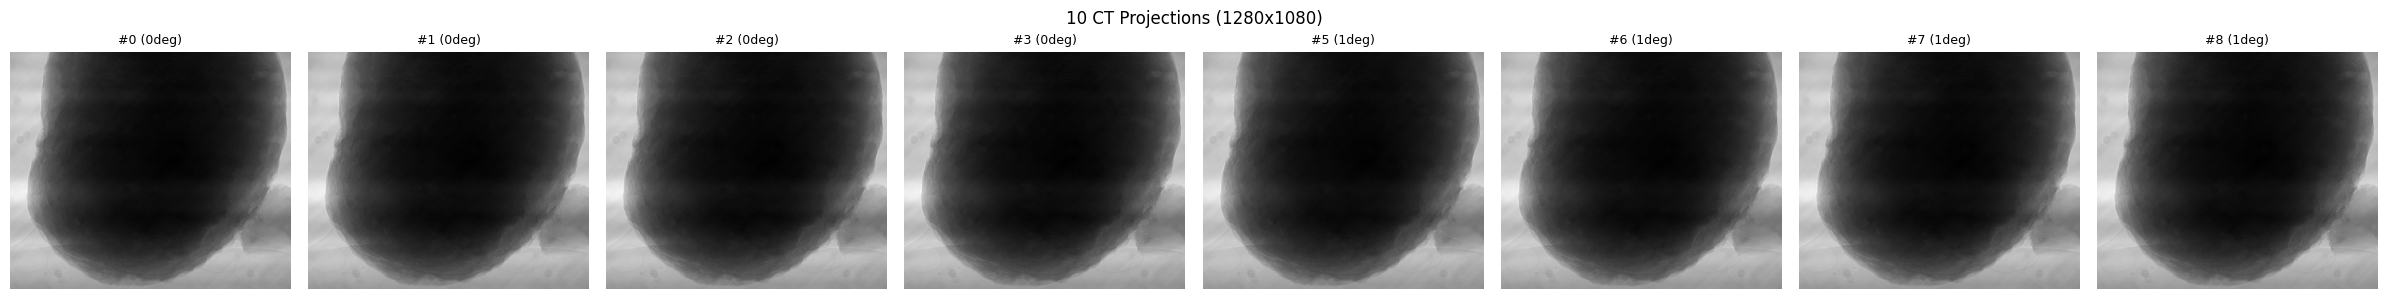

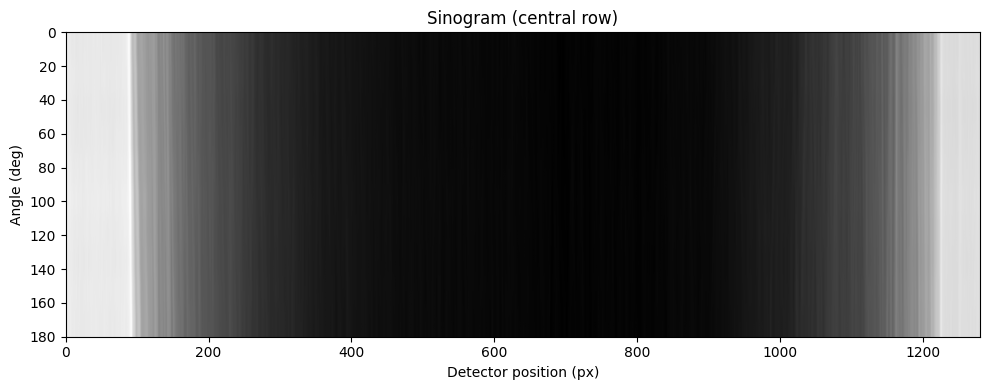

In [2]:
# ── Configuration ─────────────────────────────────────────────────────────
DATA_PATH = Path('/myhome/data/sdate/shared/compression_paper/file_1_extracted')
NUM_PROJECTIONS = 10
START_PROJECTION = 0
TARGET_SIZE = (2560//2, 2160//2)

# ── Load dataset ──────────────────────────────────────────────────────────
dataset = ProjectionSliceDataset(
    folder_path=DATA_PATH,
    num_projections=NUM_PROJECTIONS,
    target_size=TARGET_SIZE,
    start_projection=START_PROJECTION,
    normalize_values=True,
    verbose=True,
    cache_volume=True,
    use_attenuation=False,
)

# Total projections available in the scan (used for correct angle computation)
TOTAL_PROJECTIONS = dataset.processor.num_projections

volume = dataset.get_full_volume()  # (H, W, N_proj)
H, W, N_PROJ = volume.shape

# ── Global normalization to [0, 1] ───────────────────────────────────────
v_min, v_max = volume.min(), volume.max()
projections = (volume - v_min) / (v_max - v_min + 1e-8)
projections = projections.permute(2, 0, 1)  # [N_PROJ, H, W]

# Convert to RGB [N_PROJ, H, W, 3] for gsplat
gt_projections = projections.unsqueeze(-1).repeat(1, 1, 1, 3).to(device)

print(f"\nLoaded {N_PROJ} projections (indices {START_PROJECTION}–{START_PROJECTION + N_PROJ - 1} "
      f"of {TOTAL_PROJECTIONS} total), each {H}x{W}")
print(f"Value range: [{projections.min():.4f}, {projections.max():.4f}]")
print(f"GT tensor: {gt_projections.shape} on {gt_projections.device}")

# ── Display sample projections ────────────────────────────────────────────
n_show = min(8, N_PROJ)
fig, axes = plt.subplots(1, n_show, figsize=(3 * n_show, 3))
if n_show == 1:
    axes = [axes]
for i in range(n_show):
    idx = i * N_PROJ // n_show
    axes[i].imshow(projections[idx].numpy(), cmap='gray', vmin=0, vmax=1)
    angle_deg = (START_PROJECTION + idx) * 180 / TOTAL_PROJECTIONS
    axes[i].set_title(f'#{START_PROJECTION + idx} ({angle_deg:.0f}deg)', fontsize=9)
    axes[i].axis('off')
plt.suptitle(f'{N_PROJ} CT Projections ({TARGET_SIZE[0]}x{TARGET_SIZE[1]})', fontsize=12)
plt.tight_layout(); plt.show()

# ── Sinogram (row at H//2 across all angles) ─────────────────────────────
sinogram = projections[:, H // 2, :].numpy()  # [N_PROJ, W]
fig, ax = plt.subplots(figsize=(10, 4))
ax.imshow(sinogram, cmap='gray', aspect='auto',
          extent=[0, W, 180, 0])
ax.set_xlabel('Detector position (px)'); ax.set_ylabel('Angle (deg)')
ax.set_title('Sinogram (central row)'); plt.tight_layout(); plt.show()


## 3. Multi-Angle Orthographic Camera Setup

For parallel-beam CT, each projection angle $\theta$ corresponds to an orthographic camera.
Rotation is around the **z-axis** (axial direction of the sample).

At angle $\theta$, the camera coordinate system is:

| Camera axis | World direction | Maps to |
|---|---|---|
| $\mathbf{x}_{\text{cam}}$ | $(\cos\theta,\; \sin\theta,\; 0)$ | image columns (W) |
| $\mathbf{y}_{\text{cam}}$ | $(0,\; 0,\; -1)$ | image rows (H) |
| $\mathbf{z}_{\text{cam}}$ | $(-\sin\theta,\; \cos\theta,\; 0)$ | depth (compositing order) |

The view matrix $V(\theta) \in \mathbb{R}^{4 \times 4}$ transforms world → camera:
$$V(\theta) = \begin{pmatrix} \cos\theta & \sin\theta & 0 & 0 \\ 0 & 0 & -1 & 0 \\ -\sin\theta & \cos\theta & 0 & S \\ 0 & 0 & 0 & 1 \end{pmatrix}$$

where $S = \text{SIZE}$ pushes the object in front of the camera (all depths positive).

The intrinsic matrix $K$ uses the **actual image centre** for the principal point:
$$c_x = W/2, \quad c_y = H/2$$
(using $c_x = c_y = S/2$ is wrong for non-square images — e.g.\ $H{=}1080,\,S{=}1280$ gives $c_y{=}640$ instead of $540$).


In [3]:
SIZE = float(max(TARGET_SIZE))

def ct_cameras(n_proj, size, device, start_proj=0, total_n_proj=None,
               img_W=None, img_H=None):
    """Create orthographic cameras for parallel-beam CT.

    Angles are selected from a full linspace of [0, pi) with ``total_n_proj``
    steps, then sliced to ``[start_proj : start_proj + n_proj]``.  This
    ensures the angles match the physical acquisition geometry regardless of
    which subset of projections is loaded.

    Parameters
    ----------
    n_proj : int
        Number of projections to use (== len of the loaded subset).
    size : float
        World-space extent of the volume (= max(img_W, img_H)).
    device : torch.device
    start_proj : int
        Index of the first loaded projection in the full scan.
    total_n_proj : int or None
        Total projections in the full scan.  If None, defaults to ``n_proj``
        (i.e. the subset is the entire scan — preserves backward compatibility).
    img_W : int or None
        Actual image width in pixels.  Used to set K[0,2] = W/2 (c_x).
        Falls back to size/2 when None.
    img_H : int or None
        Actual image height in pixels.  Used to set K[1,2] = H/2 (c_y).
        Falls back to size/2 when None — which is WRONG for non-square images
        (e.g. H=1080, size=1280 → cy=640 instead of the correct 540).

    Returns
    -------
    viewmats : Tensor [N, 4, 4]
    K : Tensor [3, 3]
    angles : Tensor [N]  (radians)
    """
    if total_n_proj is None:
        total_n_proj = n_proj

    # Full angle grid for the complete scan
    all_angles = torch.linspace(0, math.pi, total_n_proj + 1, device=device)[:-1]
    # Select the subset that corresponds to the loaded projections
    angles = all_angles[start_proj : start_proj + n_proj]

    # Intrinsics: principal point at the actual image centre (not SIZE/2 for both axes)
    K = torch.eye(3, device=device)
    K[0, 2] = (img_W / 2.0) if img_W is not None else (size / 2.0)   # c_x = W/2
    K[1, 2] = (img_H / 2.0) if img_H is not None else (size / 2.0)   # c_y = H/2

    c = torch.cos(angles)
    s = torch.sin(angles)

    viewmats = torch.zeros(n_proj, 4, 4, device=device)
    viewmats[:, 0, 0] = c          # x_cam row
    viewmats[:, 0, 1] = s
    viewmats[:, 1, 2] = -1.0       # y_cam = (0, 0, -1)
    viewmats[:, 2, 0] = -s         # z_cam row
    viewmats[:, 2, 1] = c
    viewmats[:, 2, 3] = size       # push object to positive depth
    viewmats[:, 3, 3] = 1.0        # homogeneous

    return viewmats, K, angles


viewmats_all, K_cam, angles_all = ct_cameras(
    N_PROJ, SIZE, device,
    start_proj=START_PROJECTION,
    total_n_proj=TOTAL_PROJECTIONS,
    img_W=W, img_H=H,
)
Ks_all = K_cam[None].expand(N_PROJ, -1, -1)   # [N_PROJ, 3, 3]

angle_start_deg = angles_all[0].item() * 180 / math.pi
angle_end_deg   = angles_all[-1].item() * 180 / math.pi
print(f"Created {N_PROJ} cameras from a total scan of {TOTAL_PROJECTIONS} projections")
print(f"Angle range: [{angle_start_deg:.1f} deg, {angle_end_deg:.1f} deg]  "
      f"(indices {START_PROJECTION}–{START_PROJECTION + N_PROJ - 1})")
print(f"K (intrinsics):\n{K_cam}")
print(f"Object extent: [{-SIZE/2:.0f}, {SIZE/2:.0f}] in world coords")
print(f"Depth range:   [{SIZE/2:.0f}, {3*SIZE/2:.0f}] (all positive)")


Created 10 cameras from a total scan of 1501 projections
Angle range: [0.0 deg, 1.1 deg]  (indices 0–9)
K (intrinsics):
tensor[3, 3] n=9 x∈[0., 640.000] μ=131.444 σ=261.176 cuda:0 [[1.000, 0., 640.000], [0., 1.000, 540.000], [0., 0., 1.000]]
Object extent: [-640, 640] in world coords
Depth range:   [640, 1920] (all positive)


## 4. Initialize 3D Isotropic Gaussians

Each Gaussian has:
- **means** $(x, y, z)$: position in world coordinates $\in [-S/2, S/2]^3$
- **log\_scales** $(s, s, s)$: isotropic — same in all 3 directions (enforced after each step)
- **quats** $(1, 0, 0, 0)$: fixed identity — rotation is irrelevant for isotropic Gaussians
- **rgbs**: sigmoid-space intensity sampled from the mean projection (data-driven)
- **opacities**: sigmoid-space opacity (near 1.0 — flat sheet acts like an image stamp)

**Initialization strategy** (validated in `GSplat_Init_Experiments.ipynb`):
- Uniform pixel grid on the **middle** projection, back-projected to 3-D
- Colors sampled from the **average** of all projections via bilinear interpolation
- $\sigma = 2.75$ px, $\alpha = 0.99$ → **~38 dB PSNR at init** (no training needed)

In [4]:
N_POINTS     = 100_000
INIT_SCALE   = 2.75      # σ in world/pixel units (tuned via grid search)
INIT_OPACITY = 0.99      # near-opaque: flat sheet acts like a 2-D image stamp


def init_gaussians_3d(n_points, size, device,
                      img_H, img_W,
                      ref_projections=None,  # [N_proj, H, W] — used to sample colors
                      init_scale=2.75,
                      init_opacity=0.99,
                      seed=42,
                      ref_angle=0.0):
    """Initialize isotropic 3D Gaussians on a flat plane with data-driven colors.

    Places Gaussians on a uniform pixel grid in image space of the reference
    angle, then back-projects to 3-D world coordinates on the plane
    orthogonal to the middle viewing direction.

    **Color initialization**: each Gaussian's intensity is sampled from the
    mean of the input projections at its pixel location (bilinear interp).
    With the narrow angular range this gives ~38+ dB PSNR at init.

    Parameters
    ----------
    n_points        : int — target number of Gaussians.
    size            : float — world extent ``max(img_W, img_H)``.
    img_H, img_W    : int — rasterization dimensions in pixels.
    ref_projections : Tensor [N, H, W] or None — projections to average for
                      color sampling.  If None, falls back to uniform 0.5.
    init_scale      : float — isotropic sigma (world/pixel units).
    init_opacity    : float — opacity in [0, 1].
    ref_angle       : float — angle (radians) of the reference view.
    """
    torch.manual_seed(seed)
    cx = img_W / 2.0
    cy = img_H / 2.0

    # ── Grid matching image aspect ratio ──────────────────────────────
    aspect = img_W / img_H
    n_rows = max(2, int(math.sqrt(n_points / aspect)))
    n_cols = max(2, int(n_points / n_rows))

    cols = torch.linspace(0.5, img_W - 0.5, n_cols, device=device)
    rows = torch.linspace(0.5, img_H - 0.5, n_rows, device=device)
    gc, gr = torch.meshgrid(cols, rows, indexing='xy')
    col_flat = gc.reshape(-1).float()
    row_flat = gr.reshape(-1).float()

    # ── Back-project pixel → 3-D world ───────────────────────────────
    c0 = math.cos(ref_angle)
    s0 = math.sin(ref_angle)
    wx = (col_flat - cx) * c0
    wy = (col_flat - cx) * s0
    wz = cy - row_flat
    means = torch.stack([wx, wy, wz], dim=-1)   # [N, 3]

    # ── Sample colors from the average projection ─────────────────────
    if ref_projections is not None:
        avg_img = ref_projections.mean(dim=0).to(device)   # [H, W]
        norm_x = (col_flat / img_W) * 2 - 1
        norm_y = (row_flat / img_H) * 2 - 1
        grid_coords = torch.stack([norm_x, norm_y], dim=-1)[None, None]  # [1,1,N,2]
        sampled = F.grid_sample(
            avg_img[None, None], grid_coords,
            mode='bilinear', padding_mode='border', align_corners=False,
        ).squeeze()  # [N]
        sampled = sampled.clamp(0.01, 0.99)
        rgb_logit = torch.log(sampled / (1 - sampled))
        rgbs = rgb_logit.unsqueeze(-1).expand(-1, 3).clone()  # [N, 3]
    else:
        rgbs = torch.logit(torch.full((means.shape[0], 3), 0.5,
                                       device=device).clamp(0.01, 0.99))

    N = means.shape[0]
    log_scales = torch.full((N, 3), math.log(init_scale), device=device)
    quats      = torch.zeros(N, 4, device=device);  quats[:, 0] = 1.0
    opacities  = torch.logit(torch.full((N,), init_opacity, device=device).clamp(0.01, 0.99))

    params = GaussianParams(means, log_scales, quats, rgbs, opacities)
    params.means.requires_grad_(True)
    params.log_scales.requires_grad_(True)
    params.rgbs.requires_grad_(True)
    params.opacities.requires_grad_(True)
    return params


# ── Use the middle projection angle as reference ──────────────────────────
mid_idx   = N_PROJ // 2
mid_angle = angles_all[mid_idx].item()

params = init_gaussians_3d(
    N_POINTS, SIZE, device,
    img_H=H, img_W=W,
    ref_projections=projections,   # [N_PROJ, H, W] – averaged internally
    init_scale=INIT_SCALE,
    init_opacity=INIT_OPACITY,
    ref_angle=mid_angle,
)

pixel_spacing = math.sqrt(W * H / params.n_gaussians)
actual_scale  = math.exp(params.log_scales[0, 0].item())
print(f"Initialized {params.n_gaussians:,} Gaussians (flat, data-driven colors)")
print(f"  means:      {params.means.shape}  range x=[{params.means[:,0].min():.1f}, {params.means[:,0].max():.1f}]"
      f"  z=[{params.means[:,2].min():.1f}, {params.means[:,2].max():.1f}]")
print(f"  log_scales: init σ = {actual_scale:.2f} px  (pixel spacing ≈ {pixel_spacing:.2f} px)")
print(f"  opacity:    {INIT_OPACITY}")
print(f"  ref angle:  {mid_angle*180/math.pi:.2f}°  (middle projection)")
print(f"  colors:     sampled from mean of {projections.shape[0]} projections")


Initialized 99,760 Gaussians (flat, data-driven colors)
  means:      torch.Size([99760, 3])  range x=[-639.5, 639.5]  z=[-539.5, 539.5]
  log_scales: init σ = 2.75 px  (pixel spacing ≈ 3.72 px)
  opacity:    0.99
  ref angle:  0.60°  (middle projection)
  colors:     sampled from mean of 10 projections


## 5. Multi-View Rendering Function

Wraps `gsplat.rasterization()` to render from **C cameras at once**.
gsplat natively supports batched `viewmats` $[C, 4, 4]$ and `Ks` $[C, 3, 3]$,
returning renders of shape $[C, H, W, 3]$.

Test render: torch.Size([4, 1080, 1280, 3])
Init PSNR:  avg=38.60 dB  min=37.99  max=39.73


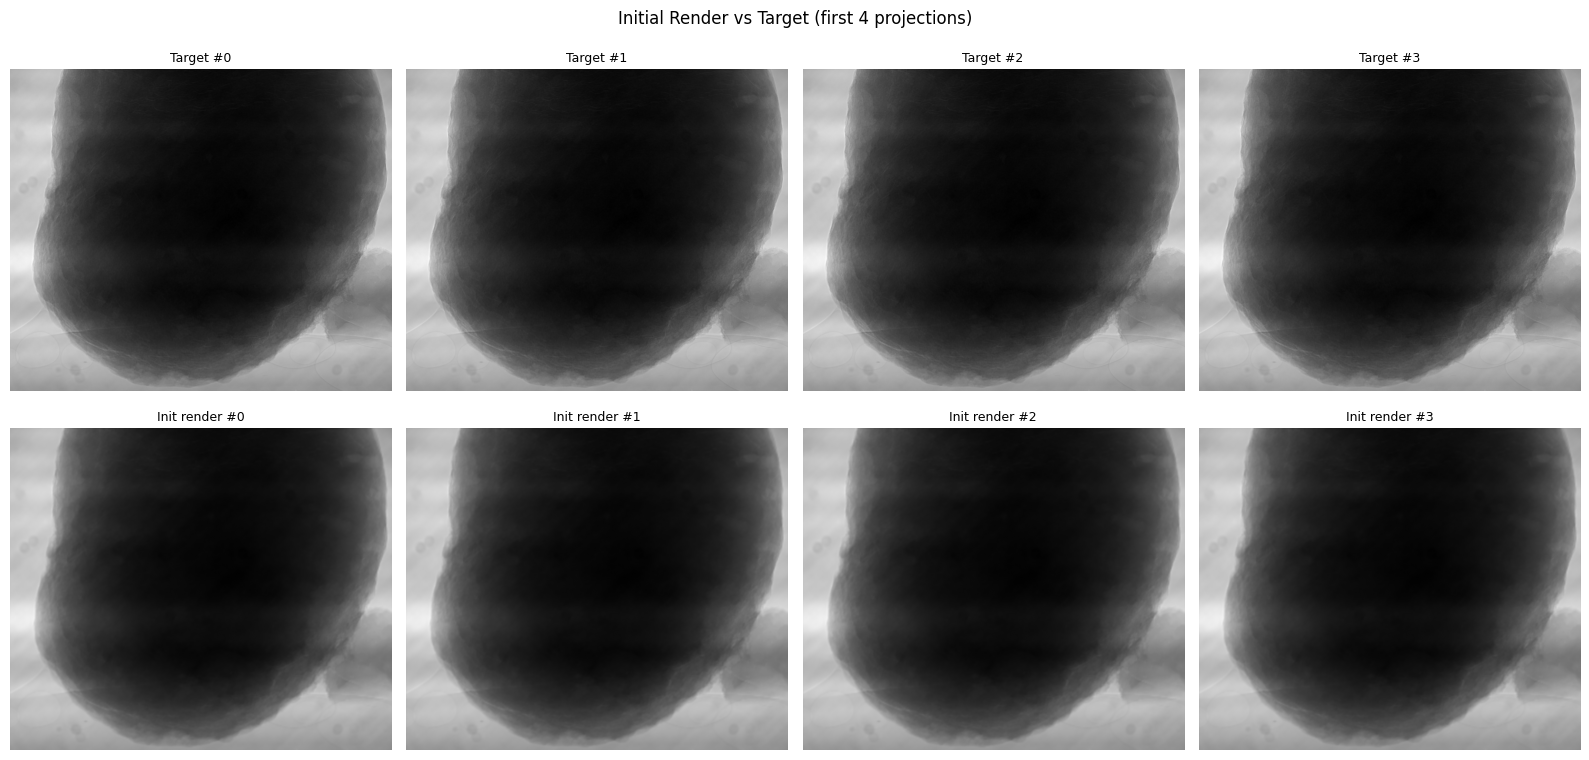

In [5]:
def render_ct(means, log_scales, quats, rgbs, opacities,
              viewmats, Ks, W, H, near_plane=0.01, far_plane=1e4):
    """Render orthographic CT projections from multiple viewpoints.

    Parameters
    ----------
    viewmats : Tensor [C, 4, 4]
    Ks : Tensor [C, 3, 3]

    Returns
    -------
    rendered : Tensor [C, H, W, 3]
    alphas : Tensor [C, H, W, 1]
    info : dict
    """
    scales = torch.exp(log_scales)
    colors = torch.sigmoid(rgbs)
    opac = torch.sigmoid(opacities)
    q = quats / quats.norm(dim=-1, keepdim=True)

    renders, alphas, info = rasterization(
        means=means,
        quats=q,
        scales=scales,
        opacities=opac,
        colors=colors,
        viewmats=viewmats,
        Ks=Ks,
        width=W,
        height=H,
        near_plane=near_plane,
        far_plane=far_plane,
        packed=False,
        camera_model="ortho",
    )
    return renders, alphas, info


# ── Quick test render from first 4 views ──────────────────────────────────
with torch.no_grad():
    test_renders, test_alphas, _ = render_ct(
        params.means, params.log_scales, params.quats,
        params.rgbs, params.opacities,
        viewmats_all[:4], Ks_all[:4], W, H,
    )
    print(f"Test render: {test_renders.shape}")

    # ── Compute init PSNR on ALL projections ──────────────────────────
    all_init = []
    for s in range(0, N_PROJ, 4):
        e = min(s + 4, N_PROJ)
        r, _, _ = render_ct(
            params.means, params.log_scales, params.quats,
            params.rgbs, params.opacities,
            viewmats_all[s:e], Ks_all[s:e], W, H,
        )
        all_init.append(r.cpu())
    all_init = torch.cat(all_init, dim=0)
    mse_per = ((all_init - gt_projections.cpu()) ** 2).mean(dim=(1, 2, 3))
    psnr_per = -10 * torch.log10(mse_per + 1e-10)
    print(f"Init PSNR:  avg={psnr_per.mean():.2f} dB  "
          f"min={psnr_per.min():.2f}  max={psnr_per.max():.2f}")

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i in range(4):
    axes[0, i].imshow(projections[i].numpy(), cmap='gray', vmin=0, vmax=1)
    axes[0, i].set_title(f'Target #{i}', fontsize=9); axes[0, i].axis('off')
    axes[1, i].imshow(test_renders[i, :, :, 0].cpu().numpy(), cmap='gray', vmin=0, vmax=1)
    axes[1, i].set_title(f'Init render #{i}', fontsize=9); axes[1, i].axis('off')
axes[0, 0].set_ylabel('Target', fontsize=10)
axes[1, 0].set_ylabel('Render', fontsize=10)
plt.suptitle('Initial Render vs Target (first 4 projections)', fontsize=12)
plt.tight_layout(); plt.show()

## 6. Training Configuration and Helpers

**Training strategy:**
- Mini-batch of `BATCH_SIZE` random projections per iteration
- Adam optimizer (means, scales, colors, opacities — **not** quaternions)
- After each step: enforce **isotropic** scales and **grayscale** colors
- Adaptive densification: prune low-opacity, split over-large Gaussians
- LR halved after the halfway point

In [6]:
# ── Hyperparameters ────────────────────────────────────────────────────────
NUM_ITERATIONS       = 15_000
BATCH_SIZE           = 4        # projections per gradient step
USE_FP16             = True
LOG_INTERVAL         = 200

LR_MEANS             = 1e-2
LR_SCALES            = 5e-3
LR_RGBS              = 1e-2
LR_OPACITIES         = 5e-2

DENSIFY_FROM         = 500
DENSIFY_INTERVAL     = 500
DENSIFY_UNTIL        = NUM_ITERATIONS - 2_000
PRUNE_OPACITY_THRESH = 0.005
SPLIT_SCALE_THRESH   = 10.0

# ── Per-projection residual Gaussians ─────────────────────────────────────
# Each projection gets its own small set of Gaussians that only contribute
# to that one angle, correcting systematic per-projection shifts/errors.
RESIDUAL_FRAC             = 0.000001   # residuals per proj as fraction of global N at init
RESIDUAL_START_PCT        = 1.2   # fraction of total iters before activating residuals
RESIDUAL_INIT_SCALE       = 2.0    # initial sigma (world units) for residual Gaussians
RESIDUAL_DENSIFY_INTERVAL = DENSIFY_INTERVAL   # same pruning cadence as global


# ── Helper functions ──────────────────────────────────────────────────────
def make_optimizer(params, lr_mult=1.0):
    """Adam optimizer — excludes quaternions (isotropic => rotation irrelevant)."""
    return optim.Adam([
        {"params": [params.means],      "lr": LR_MEANS * lr_mult},
        {"params": [params.log_scales], "lr": LR_SCALES * lr_mult},
        {"params": [params.rgbs],       "lr": LR_RGBS * lr_mult},
        {"params": [params.opacities],  "lr": LR_OPACITIES * lr_mult},
    ])


def make_residual_optimizer(res_params_list, lr_mult=1.0):
    """Adam optimizer covering all initialised per-projection residual params."""
    groups = []
    for rp in res_params_list:
        if rp is not None and rp.n_gaussians > 0:
            groups += [
                {"params": [rp.means],      "lr": LR_MEANS * lr_mult},
                {"params": [rp.log_scales], "lr": LR_SCALES * lr_mult},
                {"params": [rp.rgbs],       "lr": LR_RGBS * lr_mult},
                {"params": [rp.opacities],  "lr": LR_OPACITIES * lr_mult},
            ]
    if not groups:   # dummy so the scaler always has an optimizer to work with
        dummy = torch.zeros(1, requires_grad=True, device=device)
        return optim.Adam([dummy], lr=1e-10)
    return optim.Adam(groups, lr=LR_MEANS * lr_mult)


def enforce_isotropic(log_scales):
    """In-place: force all 3 scale dims to their mean => isotropic."""
    with torch.no_grad():
        mean_s = log_scales.data.mean(dim=-1, keepdim=True)
        log_scales.data.copy_(mean_s.expand_as(log_scales))


def enforce_grayscale(rgbs):
    """In-place: force all 3 RGB channels to their mean => single intensity."""
    with torch.no_grad():
        mean_c = rgbs.data.mean(dim=-1, keepdim=True)
        rgbs.data.copy_(mean_c.expand_as(rgbs))


def densify_ct(params, prune_thresh=None, split_thresh=None):
    """Prune low-opacity and split over-large isotropic Gaussians."""
    if prune_thresh is None:
        prune_thresh = PRUNE_OPACITY_THRESH
    if split_thresh is None:
        split_thresh = SPLIT_SCALE_THRESH
    with torch.no_grad():
        # ── Prune ─────────────────────────────────────────────────────
        opac_vals = torch.sigmoid(params.opacities)
        keep = opac_vals > prune_thresh
        n_pruned = params.n_gaussians - keep.sum().item()

        means      = params.means.data[keep].clone()
        log_scales = params.log_scales.data[keep].clone()
        quats      = params.quats.data[keep].clone()
        rgbs       = params.rgbs.data[keep].clone()
        opacities  = params.opacities.data[keep].clone()

        # ── Split over-large (isotropic: all dims equal, check dim 0) ─
        scale_vals = torch.exp(log_scales[:, 0])
        split_mask = scale_vals > split_thresh
        n_split = split_mask.sum().item()

        if n_split > 0:
            p_m = means[split_mask]
            p_s = log_scales[split_mask]
            p_q = quats[split_mask]
            p_r = rgbs[split_mask]
            p_o = opacities[split_mask]

            # Offset children along random 3D direction
            sigma = torch.exp(p_s[:, 0:1])   # [n_split, 1]
            rand_dir = torch.randn_like(p_m)
            rand_dir = rand_dir / rand_dir.norm(dim=-1, keepdim=True)
            offset = 0.5 * sigma * rand_dir

            c1_m = p_m + offset
            c2_m = p_m - offset
            c_s  = p_s - math.log(2.0)   # halve scale

            keep_rest  = ~split_mask
            means      = torch.cat([means[keep_rest],      c1_m, c2_m])
            log_scales = torch.cat([log_scales[keep_rest], c_s,  c_s.clone()])
            quats      = torch.cat([quats[keep_rest],      p_q,  p_q.clone()])
            rgbs       = torch.cat([rgbs[keep_rest],       p_r,  p_r.clone()])
            opacities  = torch.cat([opacities[keep_rest],  p_o,  p_o.clone()])

    new_params = GaussianParams(means, log_scales, quats, rgbs, opacities)
    new_params.means.requires_grad_(True)
    new_params.log_scales.requires_grad_(True)
    new_params.rgbs.requires_grad_(True)
    new_params.opacities.requires_grad_(True)
    return new_params, n_pruned, n_split


def init_residual_from_error(proj_idx, global_p, gt_proj_img, n_residual,
                              viewmat, K_mat, device, init_scale=2.0):
    """Initialise per-projection residual Gaussians at the largest-error pixels.

    Renders the current global representation for projection ``proj_idx``,
    builds a squared-error map, picks the ``n_residual`` worst pixels, and
    back-projects them to 3D world coordinates using the orthographic viewmat.

    Parameters
    ----------
    proj_idx    : int            — index (for logging only)
    global_p    : GaussianParams — current global representation
    gt_proj_img : Tensor [H,W,3] — ground-truth projection on device
    n_residual  : int            — how many residual Gaussians to create
    viewmat     : Tensor [4,4]
    K_mat       : Tensor [3,3]
    init_scale  : float          — initial isotropic sigma in world units
    """
    with torch.no_grad():
        vm = viewmat.unsqueeze(0)  # [1,4,4]
        km = K_mat.unsqueeze(0)    # [1,3,3]
        rendered, _, _ = render_ct(
            global_p.means, global_p.log_scales, global_p.quats,
            global_p.rgbs, global_p.opacities, vm, km, W, H,
        )
        rendered_gray = rendered[0, :, :, 0]       # [H, W]
        gt_gray_2d    = gt_proj_img[:, :, 0]        # [H, W]
        error_map     = (rendered_gray - gt_gray_2d) ** 2  # [H, W]

        # Top-k error pixel locations
        n_take     = min(n_residual, error_map.numel())
        _, top_idx = torch.topk(error_map.reshape(-1), n_take)
        rows = (top_idx // W).float()   # [N]
        cols = (top_idx  % W).float()   # [N]

        # ── Back-project pixel → 3D world (orthographic) ─────────────
        # Intrinsics: cam_x = col - cx,  cam_y = row - cy  (fx=fy=1)
        cx = K_mat[0, 2];  cy = K_mat[1, 2]
        cam_x = cols - cx                        # [N]
        cam_y = rows - cy                        # [N]
        cam_z = torch.full_like(cam_x, SIZE)     # fixed mid-depth

        # viewmat = [R | 0; 0  0  1 | S; 0 0 0 1]  (rotation + z-shift)
        # world = R^T @ (cam - t),  where t = viewmat[:3, 3]
        R = viewmat[:3, :3]   # [3,3]
        t = viewmat[:3,  3]   # [3]
        cam_pts     = torch.stack([cam_x, cam_y, cam_z], dim=-1) - t  # [N,3]
        world_coords = cam_pts @ R   # R applied as left-multiply ≡ R^T col-vec  [N,3]

        n_res      = world_coords.shape[0]
        log_scales = torch.full((n_res, 3), math.log(init_scale), device=device)
        quats      = torch.zeros(n_res, 4, device=device);  quats[:, 0] = 1.0
        # Start with small colour & opacity so residuals begin contributing gently
        rgbs       = torch.full((n_res, 3), math.log(0.1 / 0.9), device=device)
        opacities  = torch.full((n_res,),   math.log(0.05 / 0.95), device=device)

    res_p = GaussianParams(world_coords, log_scales, quats, rgbs, opacities)
    res_p.means.requires_grad_(True)
    res_p.log_scales.requires_grad_(True)
    res_p.rgbs.requires_grad_(True)
    res_p.opacities.requires_grad_(True)
    return res_p


def render_with_residuals(global_p, res_params_list, batch_proj_idx, viewmats, Ks, W, H):
    """Render a mini-batch, merging per-projection residuals where available.

    For each element in the batch we concatenate global + residual Gaussians
    (if that projection has residuals initialised) before rasterization.
    This gives correct alpha-compositing, not just additive blending.

    Parameters
    ----------
    global_p        : GaussianParams
    res_params_list : list[GaussianParams | None]  — length N_PROJ
    batch_proj_idx  : Tensor [B]  — indices into res_params_list
    viewmats        : Tensor [B, 4, 4]
    Ks              : Tensor [B, 3, 3]

    Returns
    -------
    renders : Tensor [B, H, W, 3]
    """
    renders = []
    for i, pidx in enumerate(batch_proj_idx.tolist()):
        vm = viewmats[i:i+1]   # [1, 4, 4]
        ks = Ks[i:i+1]         # [1, 3, 3]
        rp = res_params_list[pidx]

        if rp is None or rp.n_gaussians == 0:
            r, _, _ = render_ct(
                global_p.means, global_p.log_scales, global_p.quats,
                global_p.rgbs, global_p.opacities, vm, ks, W, H,
            )
        else:
            # Concatenate global and per-projection residual Gaussians
            means = torch.cat([global_p.means,      rp.means])
            log_s = torch.cat([global_p.log_scales, rp.log_scales])
            quats = torch.cat([global_p.quats,       rp.quats])
            rgbs  = torch.cat([global_p.rgbs,        rp.rgbs])
            opacs = torch.cat([global_p.opacities,   rp.opacities])
            r, _, _ = render_ct(means, log_s, quats, rgbs, opacs, vm, ks, W, H)
        renders.append(r)   # each [1, H, W, 3]

    return torch.cat(renders, dim=0)   # [B, H, W, 3]


print(f"Config: {NUM_ITERATIONS} iters, batch={BATCH_SIZE}, fp16={USE_FP16}")
print(f"Densify: every {DENSIFY_INTERVAL} from {DENSIFY_FROM} to {DENSIFY_UNTIL}")
print(f"LRs: means={LR_MEANS}, scales={LR_SCALES}, rgbs={LR_RGBS}, opac={LR_OPACITIES}")
print(f"Residuals: activate at {RESIDUAL_START_PCT*100:.0f}% ({int(RESIDUAL_START_PCT*NUM_ITERATIONS)} iter), "
      f"frac={RESIDUAL_FRAC}, init_scale={RESIDUAL_INIT_SCALE}")


Config: 15000 iters, batch=4, fp16=True
Densify: every 500 from 500 to 13000
LRs: means=0.01, scales=0.005, rgbs=0.01, opac=0.05
Residuals: activate at 120% (18000 iter), frac=1e-06, init_scale=2.0


## 7. Training Loop

Each iteration:
1. Sample `BATCH_SIZE` random projection indices
2. Render via `gsplat.rasterization()` (global only, or global+residuals if active)
3. Compute MSE loss between rendered and target projections
4. Backprop and update both global and residual optimizers in one backward pass
5. Enforce isotropic + grayscale constraints (global and each residual set)
6. Periodically prune + split Gaussians (global and per-projection residuals)

**Residual phase** (after `RESIDUAL_START_PCT` of training):
- Each projection gets its own small `GaussianParams` initialised at the `N_res` pixels
  with the highest squared error in the current global render
- `N_res = round(RESIDUAL_FRAC × N_global)` — ≈ 10 % of global count per projection
- Residuals are concatenated with the global Gaussians **per projection** before
  rasterization, giving correct alpha-compositing
- A single backward pass propagates gradients to both global and whichever
  per-projection residuals appear in the current batch


In [7]:
# ── Helper functions ──────────────────────────────────────────────────────
def make_optimizer_means(params, lr_mult=1.0):
    """Adam optimizer — excludes quaternions (isotropic => rotation irrelevant)."""
    return optim.Adam([
        {"params": [params.means],      "lr": LR_MEANS * lr_mult},
        # {"params": [params.log_scales], "lr": LR_SCALES * lr_mult},
        # {"params": [params.rgbs],       "lr": LR_RGBS * lr_mult},
        # {"params": [params.opacities],  "lr": LR_OPACITIES * lr_mult},
    ])

In [8]:
optimizer = make_optimizer_means(params)
scaler    = GradScaler(enabled=USE_FP16)
mse_fn    = torch.nn.MSELoss()

# ── Per-projection residual state ─────────────────────────────────────────
RESIDUAL_START_ITER = int(RESIDUAL_START_PCT * NUM_ITERATIONS)
residual_params  = [None] * N_PROJ   # one GaussianParams per projection (or None)
residuals_active = False
res_optimizer    = make_residual_optimizer(residual_params)   # dummy until activated
res_scaler       = GradScaler(enabled=USE_FP16)

loss_history      = []
psnr_history      = []
densify_iters     = []
residual_init_iter = None

t_start = time.time()
print(f"Training CT reconstruction: {NUM_ITERATIONS} iters, "
      f"N={params.n_gaussians:,}, {N_PROJ} projections, batch={BATCH_SIZE}")
print(f"Residuals activate at iter {RESIDUAL_START_ITER} "
      f"(~{int(params.n_gaussians * RESIDUAL_FRAC):,} Gaussians / projection)")
print("=" * 70)

for iteration in range(NUM_ITERATIONS):

    # ────────────────────────────────────────────────────────────────────
    # One-time: initialise per-projection residual Gaussians from error map
    # ────────────────────────────────────────────────────────────────────
    if not residuals_active and iteration == RESIDUAL_START_ITER:
        residuals_active    = True
        residual_init_iter  = iteration
        n_per_proj = max(1, int(params.n_gaussians * RESIDUAL_FRAC))
        print(f"\n[iter {iteration}] Initialising per-projection residuals: "
              f"{n_per_proj:,} Gaussians each × {N_PROJ} projections "
              f"= {n_per_proj * N_PROJ:,} total")
        for pi in range(N_PROJ):
            residual_params[pi] = init_residual_from_error(
                pi, params,
                gt_projections[pi],          # [H, W, 3]
                n_per_proj,
                viewmats_all[pi], K_cam, device,
                RESIDUAL_INIT_SCALE,
            )
        res_optimizer = make_residual_optimizer(residual_params)
        res_scaler    = GradScaler(enabled=USE_FP16)
        print(f"  Done — {sum(rp.n_gaussians for rp in residual_params):,} residual Gaussians total\n")

    # ── Mini-batch sampling ───────────────────────────────────────────
    batch_idx = torch.randint(0, N_PROJ, (BATCH_SIZE,), device=device)
    gt_batch  = gt_projections[batch_idx]   # [B, H, W, 3]
    vm_batch  = viewmats_all[batch_idx]     # [B, 4, 4]
    ks_batch  = Ks_all[batch_idx]           # [B, 3, 3]

    # ── Forward pass ──────────────────────────────────────────────────
    with autocast(device_type="cuda", dtype=torch.float16, enabled=USE_FP16):
        if residuals_active:
            rendered = render_with_residuals(
                params, residual_params, batch_idx,
                vm_batch, ks_batch, W, H,
            )
        else:
            rendered, _, _ = render_ct(
                params.means, params.log_scales, params.quats,
                params.rgbs, params.opacities,
                vm_batch, ks_batch, W, H,
            )
        loss = mse_fn(rendered, gt_batch)

    # ── Backward + update (single backward, both optimizers) ─────────
    optimizer.zero_grad()
    res_optimizer.zero_grad()
    scaler.scale(loss).backward()
    scaler.step(optimizer)
    if residuals_active:
        scaler.step(res_optimizer)
    scaler.update()

    # ── Enforce isotropic + grayscale on global params ────────────────
    enforce_isotropic(params.log_scales)
    enforce_grayscale(params.rgbs)

    # ── Enforce constraints on every active residual set ─────────────
    if residuals_active:
        for rp in residual_params:
            if rp is not None and rp.n_gaussians > 0:
                enforce_isotropic(rp.log_scales)
                enforce_grayscale(rp.rgbs)

    # ── Logging ───────────────────────────────────────────────────────
    lv = loss.item()
    pv = -10 * math.log10(lv + 1e-10)
    loss_history.append(lv)
    psnr_history.append(pv)

    if iteration % LOG_INTERVAL == 0 or iteration == NUM_ITERATIONS - 1:
        res_n = sum(rp.n_gaussians for rp in residual_params if rp is not None)
        print(f"[{iteration:5d}/{NUM_ITERATIONS}]  loss={lv:.6f}  "
              f"PSNR={pv:.2f} dB  N_global={params.n_gaussians:,}"
              + (f"  N_res={res_n:,}" if residuals_active else ""))

    # ── Adaptive densification ─────────────────────────────────────────
    if (DENSIFY_FROM <= iteration < DENSIFY_UNTIL
            and iteration % DENSIFY_INTERVAL == 0 and iteration > 0):

        # — Global params —
        n_before = params.n_gaussians
        params, n_pru, n_spl = densify_ct(params)
        lr_mult  = 0.5 if iteration > NUM_ITERATIONS // 2 else 1.0
        optimizer = make_optimizer(params, lr_mult)
        scaler    = GradScaler(enabled=USE_FP16)
        densify_iters.append(iteration)
        print(f"  -> [densify global @ {iteration}]  pruned={n_pru}  split={n_spl}  "
              f"N: {n_before:,} -> {params.n_gaussians:,}")

        # — Residual params (if active): prune + split each set independently —
        if residuals_active:
            total_res_before = sum(rp.n_gaussians for rp in residual_params if rp is not None)
            total_pru = total_spl = 0
            for pi in range(N_PROJ):
                if residual_params[pi] is not None and residual_params[pi].n_gaussians > 0:
                    residual_params[pi], rp_pru, rp_spl = densify_ct(residual_params[pi])
                    total_pru += rp_pru;  total_spl += rp_spl
            total_res_after = sum(rp.n_gaussians for rp in residual_params if rp is not None)
            res_optimizer = make_residual_optimizer(residual_params, lr_mult)
            res_scaler    = GradScaler(enabled=USE_FP16)
            print(f"  -> [densify residuals @ {iteration}]  pruned={total_pru}  split={total_spl}  "
                  f"N_res: {total_res_before:,} -> {total_res_after:,}")

elapsed = time.time() - t_start
n_res_final = sum(rp.n_gaussians for rp in residual_params if rp is not None)
print(f"\nCT training done in {elapsed:.1f}s")
print(f"Final: PSNR~{psnr_history[-1]:.2f} dB  "
      f"N_global={params.n_gaussians:,}  N_res={n_res_final:,} (across {N_PROJ} projections)")


Training CT reconstruction: 15000 iters, N=99,760, 10 projections, batch=4
Residuals activate at iter 18000 (~0 Gaussians / projection)
[    0/15000]  loss=0.000150  PSNR=38.25 dB  N_global=99,760
[  200/15000]  loss=0.000103  PSNR=39.85 dB  N_global=99,760
[  400/15000]  loss=0.000121  PSNR=39.17 dB  N_global=99,760
  -> [densify global @ 500]  pruned=0  split=0  N: 99,760 -> 99,760
[  600/15000]  loss=0.000068  PSNR=41.66 dB  N_global=99,760
[  800/15000]  loss=0.000063  PSNR=42.01 dB  N_global=99,760
[ 1000/15000]  loss=0.000056  PSNR=42.49 dB  N_global=99,760
  -> [densify global @ 1000]  pruned=0  split=0  N: 99,760 -> 99,760
[ 1200/15000]  loss=0.000051  PSNR=42.95 dB  N_global=99,760
[ 1400/15000]  loss=0.000043  PSNR=43.67 dB  N_global=99,760
  -> [densify global @ 1500]  pruned=0  split=0  N: 99,760 -> 99,760
[ 1600/15000]  loss=0.000052  PSNR=42.83 dB  N_global=99,760
[ 1800/15000]  loss=0.000051  PSNR=42.93 dB  N_global=99,760
[ 2000/15000]  loss=0.000059  PSNR=42.26 dB  N_g

## 8. Training Visualization

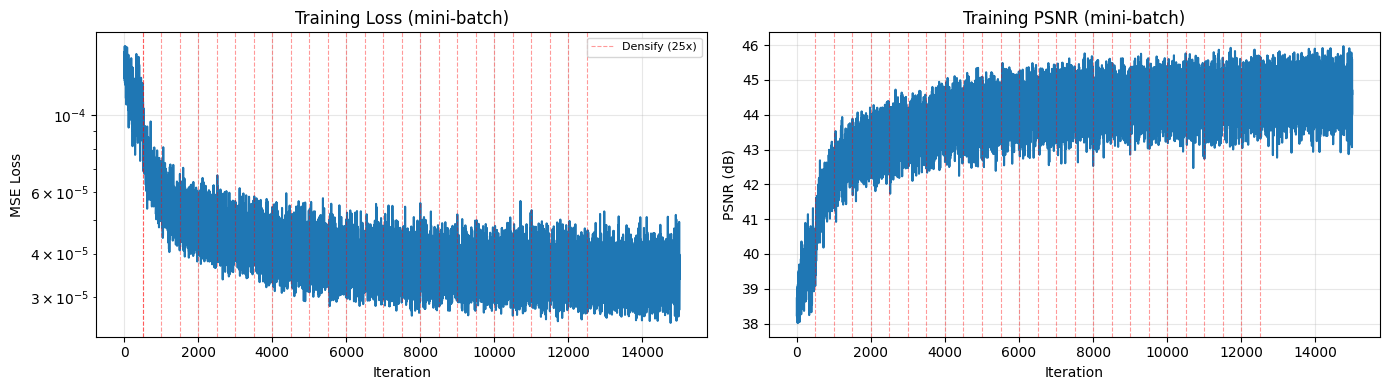

In [9]:
# ── Loss & PSNR curves ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].semilogy(loss_history)
for di in densify_iters:
    axes[0].axvline(x=di, color='r', linestyle='--', alpha=0.4, linewidth=0.8)
if densify_iters:
    axes[0].axvline(x=densify_iters[0], color='r', linestyle='--', alpha=0.4,
                    linewidth=0.8, label=f'Densify ({len(densify_iters)}x)')
    axes[0].legend(fontsize=8)
axes[0].set_xlabel('Iteration'); axes[0].set_ylabel('MSE Loss')
axes[0].set_title('Training Loss (mini-batch)'); axes[0].grid(True, alpha=0.3)

axes[1].plot(psnr_history)
for di in densify_iters:
    axes[1].axvline(x=di, color='r', linestyle='--', alpha=0.4, linewidth=0.8)
axes[1].set_xlabel('Iteration'); axes[1].set_ylabel('PSNR (dB)')
axes[1].set_title('Training PSNR (mini-batch)'); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 9. Evaluation on All Training Projections

Render from **all** $N$ angles and compute per-projection PSNR and SSIM
to assess how well the Gaussian representation reproduces the training data.

In [10]:
from skimage.metrics import structural_similarity as skimage_ssim

# ── Render all projections (global + residuals where active) ──────────────
EVAL_BATCH = 8
renders_all = []

with torch.no_grad():
    for start in range(0, N_PROJ, EVAL_BATCH):
        end      = min(start + EVAL_BATCH, N_PROJ)
        idx_t    = torch.arange(start, end, device=device)
        vm_b     = viewmats_all[start:end]
        ks_b     = Ks_all[start:end]

        if residuals_active:
            rendered = render_with_residuals(
                params, residual_params, idx_t, vm_b, ks_b, W, H,
            )
        else:
            rendered, _, _ = render_ct(
                params.means, params.log_scales, params.quats,
                params.rgbs, params.opacities, vm_b, ks_b, W, H,
            )
        renders_all.append(rendered.cpu())

renders_all  = torch.cat(renders_all, dim=0)    # [N_PROJ, H, W, 3]
renders_gray = renders_all[:, :, :, 0].numpy()  # [N_PROJ, H, W]
gt_gray      = projections.numpy()

# ── Per-projection metrics ────────────────────────────────────────────────
eval_psnrs = []
eval_ssims = []
eval_mses  = []

for i in range(N_PROJ):
    pred = np.clip(renders_gray[i], 0, 1)
    gt   = gt_gray[i]
    mse_val  = np.mean((pred - gt) ** 2)
    psnr_val = -10 * np.log10(mse_val + 1e-10)
    ssim_val = skimage_ssim(gt, pred, data_range=1.0)
    eval_psnrs.append(psnr_val)
    eval_ssims.append(ssim_val)
    eval_mses.append(mse_val)

# ── Summary ───────────────────────────────────────────────────────────────
n_res_eval = sum(rp.n_gaussians for rp in residual_params if rp is not None)
print(f"{'=' * 60}")
print(f"  CT RECONSTRUCTION METRICS ({N_PROJ} projections, {H}x{W})")
print(f"{'=' * 60}")
print(f"  Average PSNR:  {np.mean(eval_psnrs):.2f} dB  "
      f"(min={np.min(eval_psnrs):.2f}, max={np.max(eval_psnrs):.2f})")
print(f"  Average SSIM:  {np.mean(eval_ssims):.4f}  "
      f"(min={np.min(eval_ssims):.4f}, max={np.max(eval_ssims):.4f})")
print(f"  Average MSE:   {np.mean(eval_mses):.6f}")
print(f"  N global:      {params.n_gaussians:,}")
print(f"  N residual:    {n_res_eval:,}  ({'active' if residuals_active else 'not used'})")
print(f"  Training time: {elapsed:.1f}s")
print(f"{'=' * 60}")


  CT RECONSTRUCTION METRICS (10 projections, 1080x1280)
  Average PSNR:  44.68 dB  (min=42.92, max=46.06)
  Average SSIM:  0.9780  (min=0.9726, max=0.9812)
  Average MSE:   0.000035
  N global:      99,807
  N residual:    0  (not used)
  Training time: 116.3s


## 10. Results Visualization

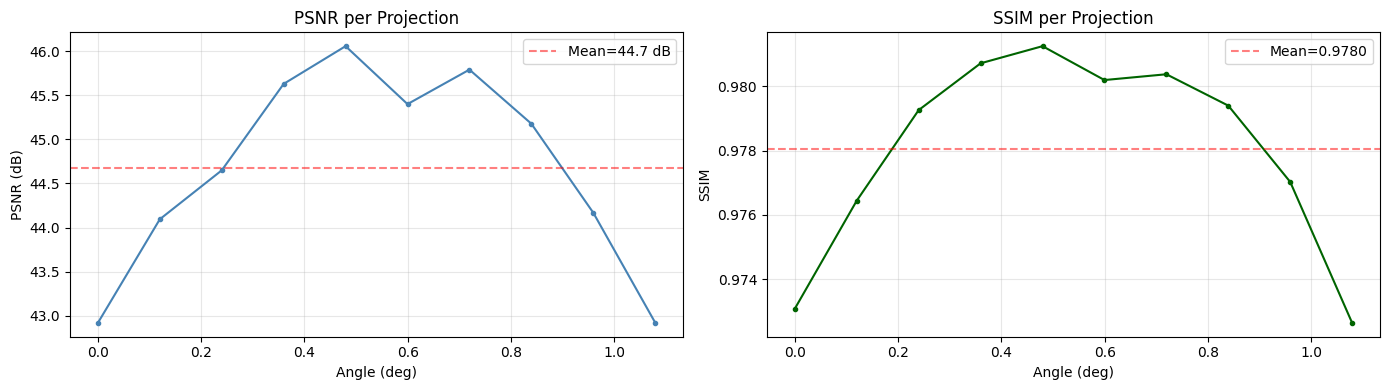

In [11]:
# ── Per-projection metrics vs angle ───────────────────────────────────────
x_angles = np.array([a.item() * 180 / math.pi for a in angles_all.cpu()])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(x_angles, eval_psnrs, 'o-', markersize=3, color='steelblue')
axes[0].axhline(np.mean(eval_psnrs), color='r', linestyle='--', alpha=0.5,
                label=f'Mean={np.mean(eval_psnrs):.1f} dB')
axes[0].set_xlabel('Angle (deg)'); axes[0].set_ylabel('PSNR (dB)')
axes[0].set_title('PSNR per Projection'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(x_angles, eval_ssims, 'o-', markersize=3, color='darkgreen')
axes[1].axhline(np.mean(eval_ssims), color='r', linestyle='--', alpha=0.5,
                label=f'Mean={np.mean(eval_ssims):.4f}')
axes[1].set_xlabel('Angle (deg)'); axes[1].set_ylabel('SSIM')
axes[1].set_title('SSIM per Projection'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

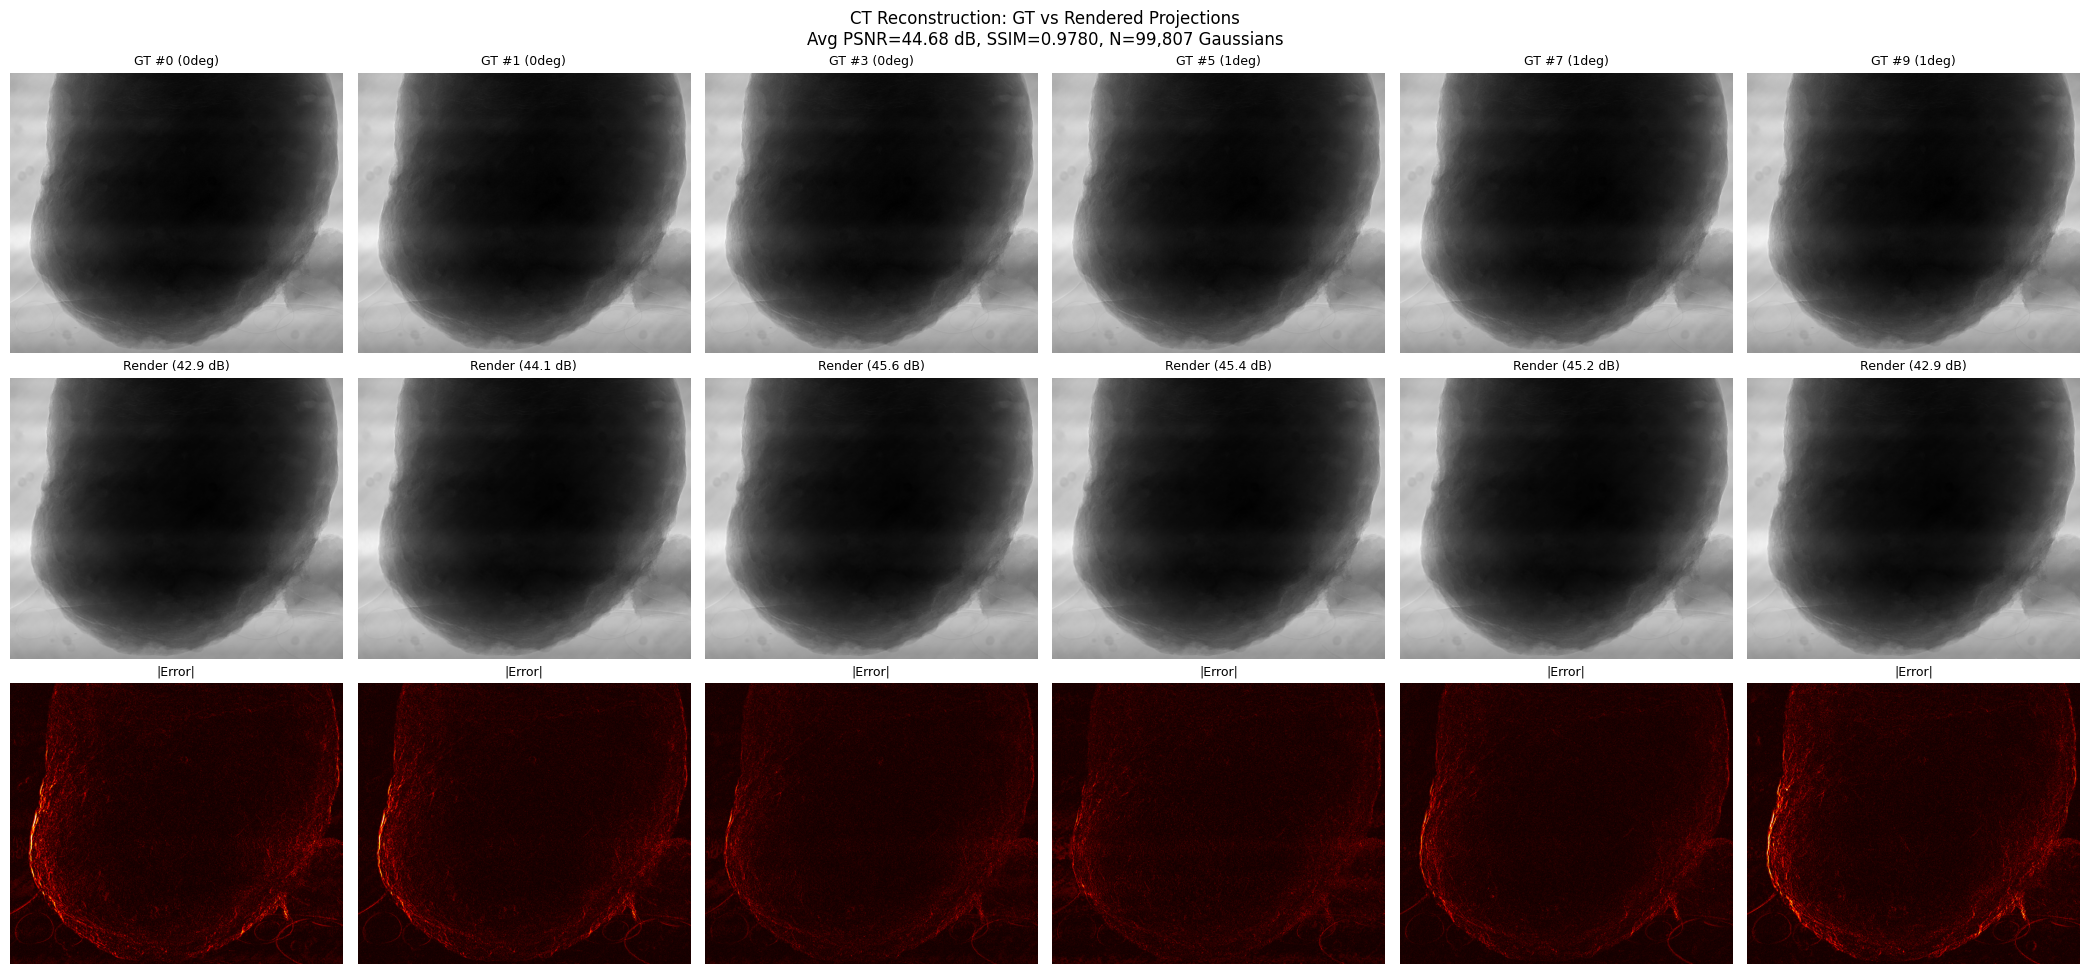

In [12]:
# ── Sample comparisons: GT vs Rendered ─────────────────────────────────────
n_show = 6
show_idx = np.linspace(0, N_PROJ - 1, n_show, dtype=int)

fig, axes = plt.subplots(3, n_show, figsize=(3.5 * n_show, 10))
for j, idx in enumerate(show_idx):
    gt_np   = gt_gray[idx]
    pred_np = np.clip(renders_gray[idx], 0, 1)
    err_np  = np.abs(pred_np - gt_np)

    axes[0, j].imshow(gt_np, cmap='gray', vmin=0, vmax=1)
    axes[0, j].set_title(f'GT #{idx} ({x_angles[idx]:.0f}deg)', fontsize=9)
    axes[0, j].axis('off')
    axes[1, j].imshow(pred_np, cmap='gray', vmin=0, vmax=1)
    axes[1, j].set_title(f'Render ({eval_psnrs[idx]:.1f} dB)', fontsize=9)
    axes[1, j].axis('off')
    axes[2, j].imshow(err_np, cmap='hot', vmin=0, vmax=0.1)
    axes[2, j].set_title('|Error|', fontsize=9)
    axes[2, j].axis('off')

axes[0, 0].set_ylabel('Target', fontsize=10)
axes[1, 0].set_ylabel('Rendered', fontsize=10)
axes[2, 0].set_ylabel('Error', fontsize=10)
plt.suptitle(f'CT Reconstruction: GT vs Rendered Projections\n'
             f'Avg PSNR={np.mean(eval_psnrs):.2f} dB, '
             f'SSIM={np.mean(eval_ssims):.4f}, '
             f'N={params.n_gaussians:,} Gaussians', fontsize=12)
plt.tight_layout(); plt.show()

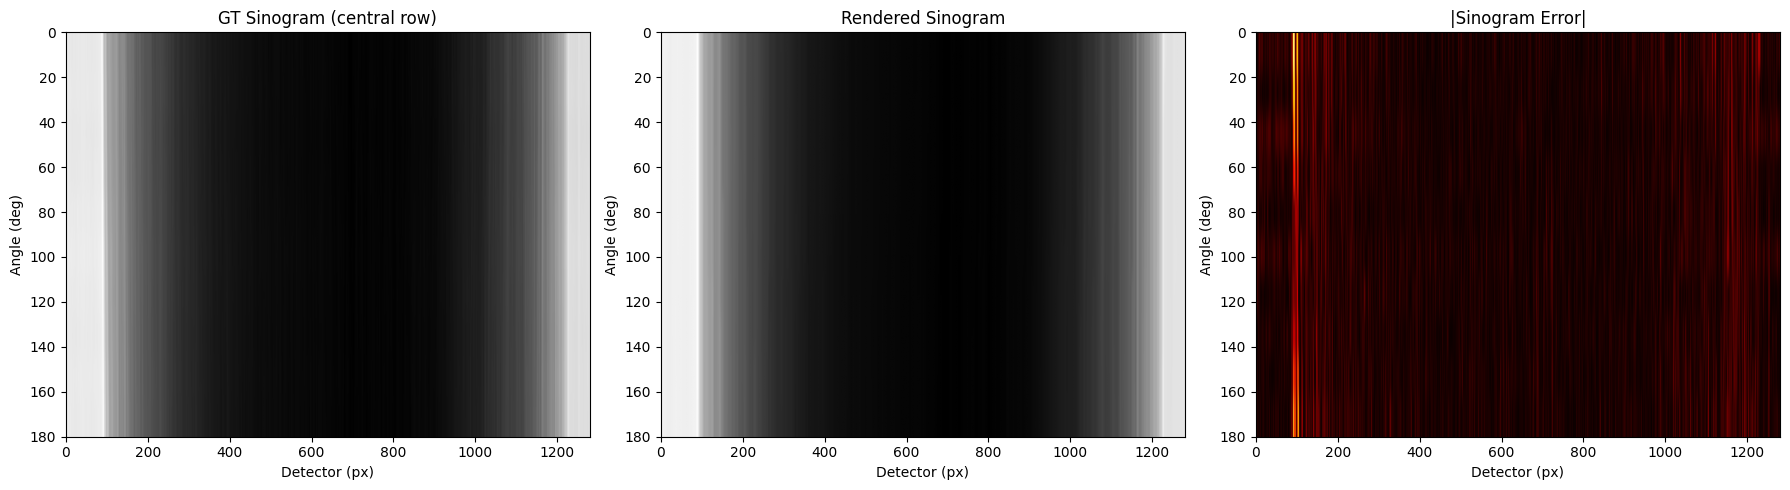

In [13]:
# ── Sinogram comparison ───────────────────────────────────────────────────
sino_gt   = gt_gray[:, H // 2, :]       # [N_PROJ, W]
sino_pred = np.clip(renders_gray[:, H // 2, :], 0, 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].imshow(sino_gt, cmap='gray', aspect='auto', extent=[0, W, 180, 0])
axes[0].set_xlabel('Detector (px)'); axes[0].set_ylabel('Angle (deg)')
axes[0].set_title('GT Sinogram (central row)')
axes[1].imshow(sino_pred, cmap='gray', aspect='auto', extent=[0, W, 180, 0])
axes[1].set_xlabel('Detector (px)'); axes[1].set_ylabel('Angle (deg)')
axes[1].set_title('Rendered Sinogram')
axes[2].imshow(np.abs(sino_pred - sino_gt), cmap='hot', aspect='auto',
               extent=[0, W, 180, 0], vmin=0, vmax=0.1)
axes[2].set_xlabel('Detector (px)'); axes[2].set_ylabel('Angle (deg)')
axes[2].set_title('|Sinogram Error|')
plt.tight_layout(); plt.show()

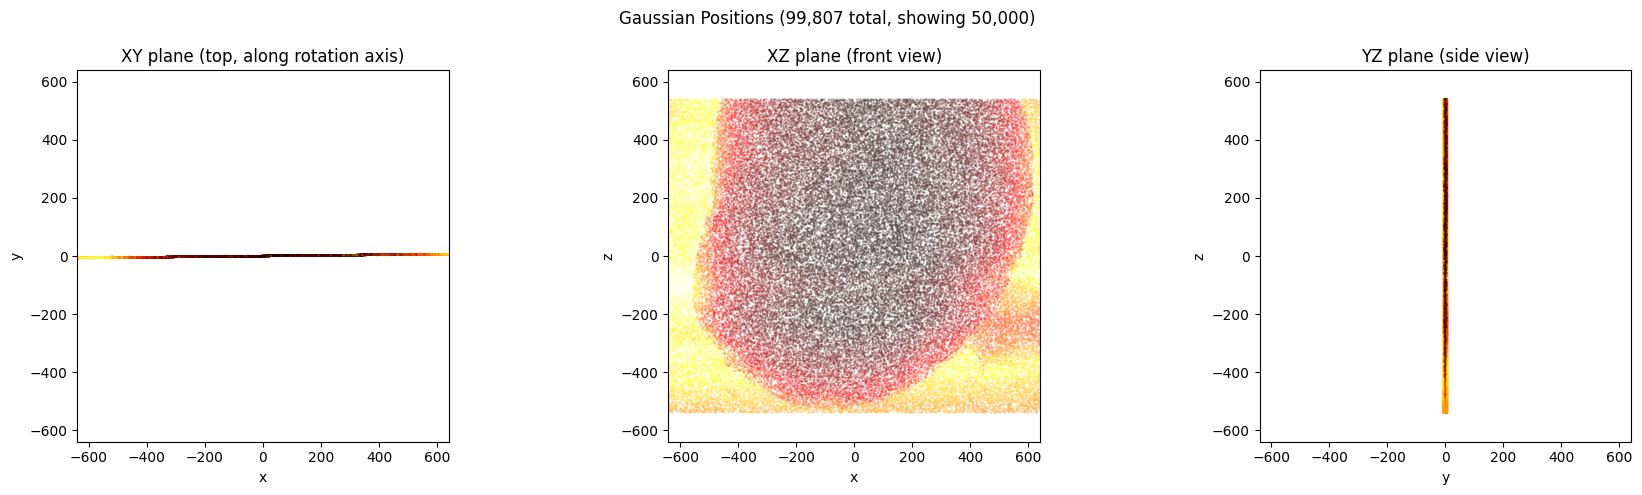

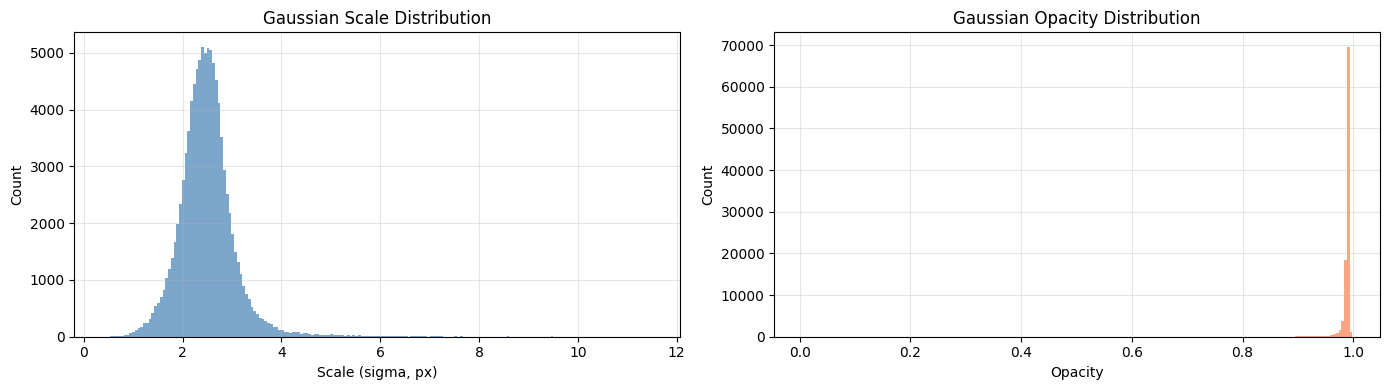


  FINAL CT RECONSTRUCTION SUMMARY
  Projections:    10 x (1080x1280)
  Angles:         [0 deg, 162.0 deg]
  Gaussians:      99,807
  Isotropic:      Yes (single sigma per Gaussian)
  Avg PSNR:       44.68 dB
  Avg SSIM:       0.9780
  Training time:  116.3s
  Iterations:     15,000
  Batch size:     4 projections/iter


In [14]:
# ── 3D Gaussian positions (2D projections of the point cloud) ─────────────
means_np = params.means.detach().cpu().numpy()
opac_np  = torch.sigmoid(params.opacities).detach().cpu().numpy()
color_np = torch.sigmoid(params.rgbs[:, 0]).detach().cpu().numpy()

n_show_pts = min(50_000, means_np.shape[0])
idx_pts = np.random.choice(means_np.shape[0], n_show_pts, replace=False)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# XY plane (top view → looking down z-axis, i.e. along rotation axis)
sc = axes[0].scatter(means_np[idx_pts, 0], means_np[idx_pts, 1],
                     c=color_np[idx_pts], cmap='hot', s=0.3, alpha=0.3)
axes[0].set_xlabel('x'); axes[0].set_ylabel('y')
axes[0].set_title('XY plane (top, along rotation axis)'); axes[0].set_aspect('equal')
axes[0].set_xlim(-SIZE/2, SIZE/2); axes[0].set_ylim(-SIZE/2, SIZE/2)

# XZ plane (front view)
axes[1].scatter(means_np[idx_pts, 0], means_np[idx_pts, 2],
                c=color_np[idx_pts], cmap='hot', s=0.3, alpha=0.3)
axes[1].set_xlabel('x'); axes[1].set_ylabel('z')
axes[1].set_title('XZ plane (front view)'); axes[1].set_aspect('equal')
axes[1].set_xlim(-SIZE/2, SIZE/2); axes[1].set_ylim(-SIZE/2, SIZE/2)

# YZ plane (side view)
axes[2].scatter(means_np[idx_pts, 1], means_np[idx_pts, 2],
                c=color_np[idx_pts], cmap='hot', s=0.3, alpha=0.3)
axes[2].set_xlabel('y'); axes[2].set_ylabel('z')
axes[2].set_title('YZ plane (side view)'); axes[2].set_aspect('equal')
axes[2].set_xlim(-SIZE/2, SIZE/2); axes[2].set_ylim(-SIZE/2, SIZE/2)

plt.suptitle(f'Gaussian Positions ({params.n_gaussians:,} total, showing {n_show_pts:,})',
             fontsize=12)
plt.tight_layout(); plt.show()

# ── Scale and opacity distributions ──────────────────────────────────────
scales = torch.exp(params.log_scales[:, 0]).detach().cpu().numpy()
opacs  = torch.sigmoid(params.opacities).detach().cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(scales, bins=200, color='steelblue', alpha=0.7)
axes[0].set_xlabel('Scale (sigma, px)'); axes[0].set_ylabel('Count')
axes[0].set_title('Gaussian Scale Distribution'); axes[0].grid(True, alpha=0.3)
axes[1].hist(opacs, bins=200, color='coral', alpha=0.7)
axes[1].set_xlabel('Opacity'); axes[1].set_ylabel('Count')
axes[1].set_title('Gaussian Opacity Distribution'); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# ── Final summary ─────────────────────────────────────────────────────────
print(f"\n{'=' * 60}")
print(f"  FINAL CT RECONSTRUCTION SUMMARY")
print(f"{'=' * 60}")
print(f"  Projections:    {N_PROJ} x ({H}x{W})")
print(f"  Angles:         [0 deg, {180 * (N_PROJ - 1) / N_PROJ:.1f} deg]")
print(f"  Gaussians:      {params.n_gaussians:,}")
print(f"  Isotropic:      Yes (single sigma per Gaussian)")
print(f"  Avg PSNR:       {np.mean(eval_psnrs):.2f} dB")
print(f"  Avg SSIM:       {np.mean(eval_ssims):.4f}")
print(f"  Training time:  {elapsed:.1f}s")
print(f"  Iterations:     {NUM_ITERATIONS:,}")
print(f"  Batch size:     {BATCH_SIZE} projections/iter")
print(f"{'=' * 60}")